## Analysis of finite temperature data for the grasshopper model

This notebook requires the following files:

- results.dat
- finconf.dat
- energies.dat
- optional: file containing the zero-temperature boundary

The following data analysis routines are performed:

- analyze energy/probability data and find out when the system is thermalized
- compute mean, variance, and higher moments of the thermalized energy
- check the shape of the energy distribution
- example of how to compute the error bar on the above observables using bootstrap
- plot the final configuration in regular and polar representation, plot histogram of radii
- rescale histogram and find boundary width using fit to the Fermi function
- routine to divide out the cogwheel boundary (needed at lower temperatures when visible cogs are present) and then refit to the Fermi function
- several Fourier analysis routines (not very conclusive)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# read in data files and parameter values
# this notebook must either be in the same folder as the data
# or need to give full paths of locations of data

with open("../runs/d0.27_N100000_T10/result.dat") as f:
    lines = f.readlines()
    jump = lines[3].strip().split(" ")[-1]
    gridsize = int(lines[5].strip().split(" ")[-1])
    
finconf = np.loadtxt("../runs/d0.27_N100000_T10/finconf.dat", dtype = int)
numberspins = len(finconf)
cellwidth = numberspins**(-1/2)

energy = np.loadtxt("../runs/d0.27_N100000_T10/energies.dat", dtype = float)

print("d = ", jump)
print("N = ", numberspins)
print("grid size = ", gridsize)
print("cell width = ", cellwidth)

d =  0.27
N =  100000
grid size =  550
cell width =  0.0031622776601683794


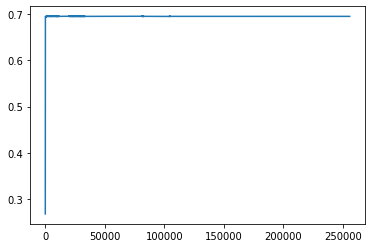

In [3]:
# plot energy

plt.plot(energy)
plt.show()

chosen cutoff =  713
mean =  0.6954499015203192 , std =  5.221574334187649e-05 , var =  2.7264838527447187e-09
Binder cumulant =  -0.018278374529994368


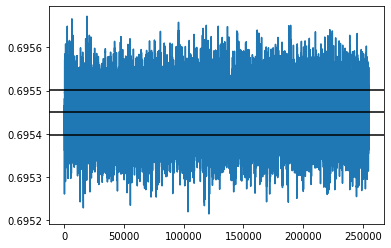

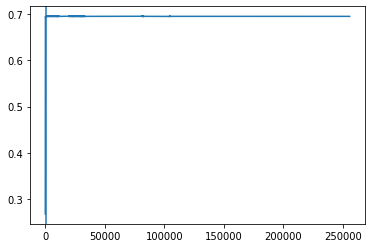

In [4]:
# determine when the system has thermalized
# this is my approach (feel free to do it differently!):
# preliminary cutoff: only consider last 10% of the data 
# determine preliminary mean & std
# find updated cutoff: first time when energy is within 1std of preliminary mean
    
cutoff = len(energy)//10
    
energymean = np.mean(energy[-cutoff:])
energystd = np.std(energy[-cutoff:])

for i in range(len(energy)):
    if abs(energy[i]-energymean)<energystd:
        cutoff=i
        break

print("chosen cutoff = ", cutoff)

# might need to manually adjust the cutoff
# cutoff=7000
# print("manually adjusted cutoff = ", cutoff)

energymean = np.mean(energy[cutoff:])
energystd = np.std(energy[cutoff:])
energyvar = np.var(energy[cutoff:])
print("mean = ", energymean, ", std = ", energystd, ", var = ", energyvar)

# higher moments
from scipy.stats import moment
binder_cumulant = 1-moment(energy[cutoff:], 4)/3/moment(energy[cutoff:], 2)**2
print("Binder cumulant = ", binder_cumulant) # should be near 0 for Gaussian distribution

# zoom in on the energy plot when system is thermalized
plt.plot(energy[cutoff:])
plt.axhline(energymean, color = 'k')
plt.axhline(energymean+energystd, color = 'k')
plt.axhline(energymean-energystd, color = 'k')
plt.show()

# compare with the full evolution, cutoff looks reasonable
plt.plot(energy)
plt.axvline(cutoff)
plt.show()

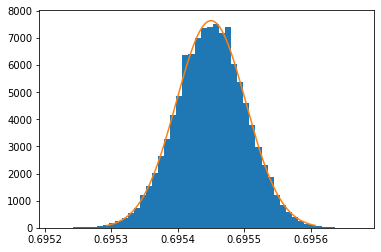

In [5]:
# check if energy distribution looks Gaussian

x = np.linspace(energymean-3*energystd,energymean+3*energystd,200)
y = np.exp(-(x-energymean)**2/2/energyvar)/np.sqrt(2*np.pi*energyvar)

plt.hist(energy[cutoff:], density=True, bins=50)
plt.plot(x, y)
plt.show()

In [6]:
# systematically compute error bar on energy variance (for specific heat)
# using the bootstrap method, see B. Efron, Ann. Statist. 7, 1 (1979)

rng = np.random.default_rng()

# total number of data points

energy_cut = energy[cutoff:]
num_pts = len(energy_cut)
print("Number sample points: ", num_pts)

# draw a random sample from the original data set having the same total num_pts, 
# but with repetitions
# repeat this num_sets times

num_sets = 1000
energy_list = []
for i in range(num_sets):
    sample = rng.integers(num_pts, size=num_pts)
    energy_list.append(energy_cut[sample])
    
energy_list = np.array(energy_list)

# compute the variances of the resampled data sets
variance_list = np.var(energy_list,axis=1)

print("Original variance: ", energyvar)
print("Mean of bootstrapped variances: ", np.mean(variance_list))
print("Bias: ", energyvar-np.mean(variance_list))
print("Error bar: ", np.std(variance_list)/np.sqrt(num_sets))

Number sample points:  255078
Original variance:  2.7264838527447187e-09
Mean of bootstrapped variances:  2.7268599415444587e-09
Bias:  -3.76088799739949e-13
Error bar:  2.3585731999474353e-13


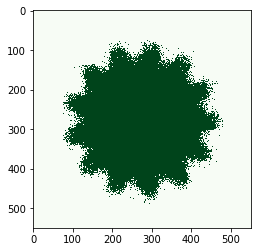

In [7]:
# plot final configuration

# note that we can get additional intermediate configurations from config.dat
# we just need to make sure that the system has already thermalized
# the above cell (and "config_average.py" from "tools") show how this can be done

unraveled = np.unravel_index(finconf, (gridsize, gridsize))
grid = np.zeros((gridsize, gridsize), dtype=int)
grid[unraveled] = 1

plt.imshow(grid, interpolation='None', cmap='Greens')
plt.show()

In [8]:
# configuration center of mass

com=np.zeros(2)

for i in range(gridsize):
    for j in range(gridsize):
        com[0]+=grid[i,j]*i
        com[1]+=grid[i,j]*j
            
com = com/np.sum(grid)

print(com)

[278.24783 273.42086]


r_0 =  0.5641895835477563


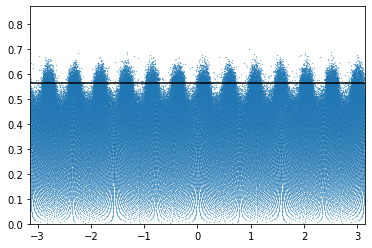

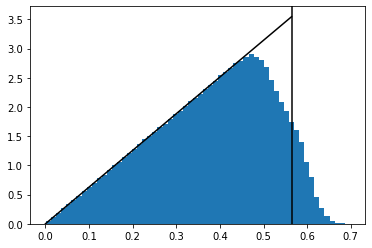

In [9]:
# configuration polar representation

phi = []
rho = []
r0 = np.sqrt(1/np.pi)   # radius of the unit area disc
print("r_0 = ", r0)

for i in range(gridsize):
    for j in range(gridsize):
        if grid[i,j] == 1:
            x = (i - com[0])*cellwidth
            y = (j - com[1])*cellwidth
            phi.append(np.arctan2(y,x))
            rho.append(np.sqrt(x*x+y*y))

# plot of rho vs phi
# this data set looks uniform in phi, horizontal line is r0
# note low densities at low r due to polar measure r*dr
plt.xlim(-np.pi,np.pi)
# better to cut off the corners of the grid, to avoid artefacts due to square grid:
plt.ylim(0,gridsize/2*cellwidth)
plt.scatter(phi, rho, s=0.05)
plt.axhline(r0, color='k')
plt.show()

# histogram of radii, integrated over phi
# vertical line is r0
# black lines are connecting this histogram with the one of the solid disk, see below
# we can extract the width of the boundary from this histogram
bins=60
plt.hist(rho, bins=bins, density=True)
plt.axvline(r0, color='k')
hor = np.linspace(0,r0,100)
plt.plot(hor, 2*np.pi*hor, color='k')
plt.show()

In [10]:
# rescale histogram by dividing by measure 2*pi*rho
# fit Fermi function to determine width

def fermi_fn(x,width):
    return 1/(1+np.exp((x-r0)/width))

hist, bin_edges = np.histogram(rho, bins=bins, density=True)

rho_values = (bin_edges[:-1]+bin_edges[1:])/2

width =  0.03279655843152452


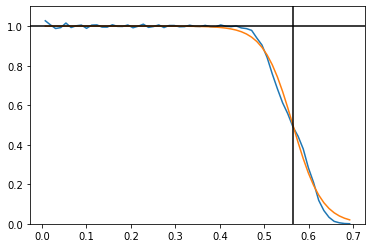

In [11]:
# systematic fit to Fermi function
from scipy.optimize import curve_fit

popt, pcov = curve_fit(fermi_fn, rho_values, hist/rho_values/2/np.pi)
print("width = ", popt[0])

plt.plot(rho_values, hist/rho_values/2/np.pi)
plt.plot(rho_values, fermi_fn(rho_values,popt[0]))
plt.axvline(r0, color='k')
plt.axhline(1, color='k')
plt.ylim(0,1.1)
plt.show()

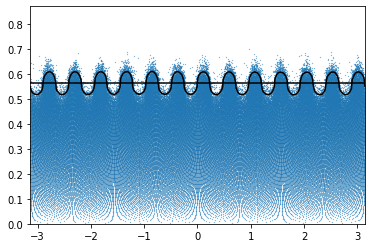

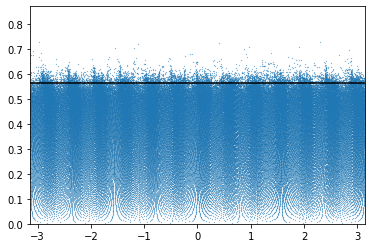

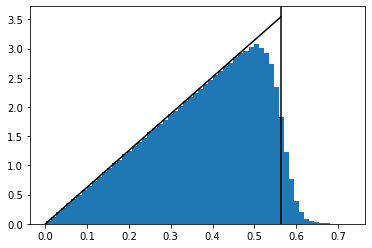

width =  0.01754862549740156


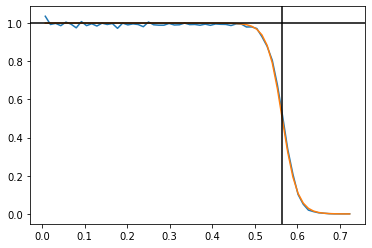

In [14]:
# try dividing out the boundary

from scipy.interpolate import make_interp_spline

polar_coordinates = np.loadtxt('../runs/d0.27_N100000_T10/d0.27_boundary.txt')

# shift to have the same phase as data (is seems easiest to shift the boundary)
cogs = 13
freq = 2*np.pi/cogs
shift = 0.29*freq     # vary this number until visual agreement and minimal width
scale = 0.67          # reduce also height of cogs => could also be important observable
polar_coordinates[:,0] += shift
polar_coordinates[polar_coordinates[:,0] > np.pi,0] -= 2*np.pi
polar_coordinates = polar_coordinates[polar_coordinates[:, 0].argsort()]
polar_coordinates[:,1] = (polar_coordinates[:,1]-r0)*scale+r0

bspl = make_interp_spline(polar_coordinates[:,0],polar_coordinates[:,1]/r0, k=1)

# plot together with data

plt.xlim(-np.pi,np.pi)
plt.ylim(0,gridsize/2*cellwidth)
plt.scatter(phi, rho, s=0.05)
x_for_plot = np.linspace(-np.pi,np.pi,500)
plt.plot(x_for_plot, bspl(x_for_plot)*r0, color = 'k')
plt.axhline(r0, color='k')
plt.show()

plt.xlim(-np.pi,np.pi)
plt.ylim(0,gridsize/2*cellwidth)
plt.scatter(phi, rho/bspl(phi), s=0.05)
plt.axhline(r0, color='k')
plt.show()

bins=60
plt.hist(rho/bspl(phi), bins=bins, density=True)
plt.axvline(r0, color='k')
hor = np.linspace(0,r0,100)
plt.plot(hor, 2*np.pi*hor, color='k')
plt.show()

# width fit

hist, bin_edges = np.histogram(rho/bspl(phi), bins=bins, density=True)

rho_values = (bin_edges[:-1]+bin_edges[1:])/2

popt, pcov = curve_fit(fermi_fn, rho_values, hist/rho_values/2/np.pi)
print("width = ", popt[0])

plt.plot(rho_values, hist/rho_values/2/np.pi)
plt.plot(rho_values, fermi_fn(rho_values,popt[0]))
plt.axvline(r0, color='k')
plt.axhline(1, color='k')

plt.show()

Best shift and scale:  0.13002812692530466 0.7500112650290998
Best width:  0.016605117929662554


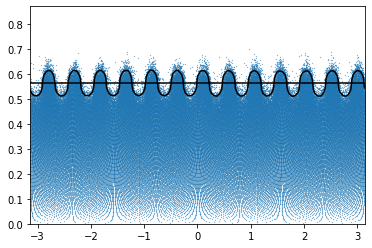

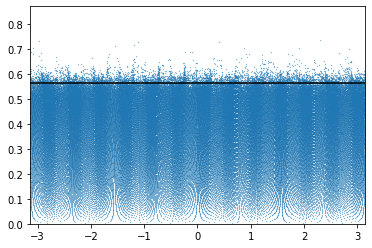

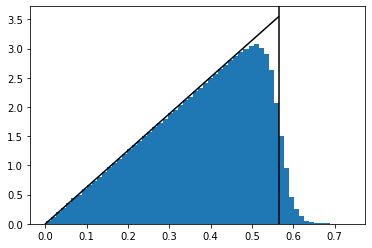

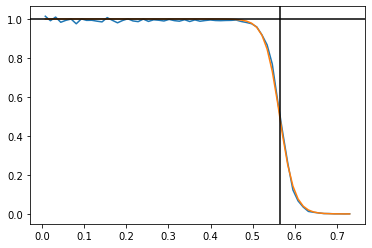

In [15]:
# systematic boundary removal
# the criterion is that the boundary width should be minimal

from scipy.interpolate import make_interp_spline
from scipy.optimize import minimize

# this function reads in the raw boundary data, shifts + scales it
# returns interpolating spline
def process_boundary(shift, scale):
    
    polar_coordinates = np.loadtxt('../runs/d0.27_N100000_T10/d0.27_boundary.txt')
    polar_coordinates[:,0] += shift
    polar_coordinates[polar_coordinates[:,0] > np.pi,0] -= 2*np.pi
    polar_coordinates = polar_coordinates[polar_coordinates[:, 0].argsort()]
    polar_coordinates[:,1] = (polar_coordinates[:,1]-r0)*scale+r0
    
    bspl = make_interp_spline(polar_coordinates[:,0],polar_coordinates[:,1]/r0, k=1)
    
    return bspl

def fitted_width(params):
    
    bspl = process_boundary(params[0], params[1])
    hist, bin_edges = np.histogram(rho/bspl(phi), bins=bins, density=True)
    rho_values = (bin_edges[:-1]+bin_edges[1:])/2

    popt, pcov = curve_fit(fermi_fn, rho_values, hist/rho_values/2/np.pi)
    return popt[0]

# adjust number of cogs based on simulation
cogs = 13
freq = 2*np.pi/cogs

# boundary minimization, start with no shift and no scaling
x0 = np.array([0, 1])
bnds = ((0, freq), (0, 1))
res = minimize(fitted_width, x0, method='powell', bounds = bnds, tol=1e-6)
shift = res.x[0]
scale = res.x[1]
width = fitted_width(res.x)
print("Best shift and scale: ", shift, scale)
print("Best width: ", width)

# plot final results
bspl = process_boundary(shift, scale)

plt.xlim(-np.pi,np.pi)
plt.ylim(0,gridsize/2*cellwidth)
plt.scatter(phi, rho, s=0.05)
x_for_plot = np.linspace(-np.pi,np.pi,500)
plt.plot(x_for_plot, bspl(x_for_plot)*r0, color = 'k')
plt.axhline(r0, color='k')
plt.show()

plt.xlim(-np.pi,np.pi)
plt.ylim(0,gridsize/2*cellwidth)
plt.scatter(phi, rho/bspl(phi), s=0.05)
plt.axhline(r0, color='k')
plt.show()

bins=60
plt.hist(rho/bspl(phi), bins=bins, density=True)
plt.axvline(r0, color='k')
hor = np.linspace(0,r0,100)
plt.plot(hor, 2*np.pi*hor, color='k')
plt.show()

hist, bin_edges = np.histogram(rho/bspl(phi), bins=bins, density=True)
rho_values = (bin_edges[:-1]+bin_edges[1:])/2

plt.plot(rho_values, hist/rho_values/2/np.pi)
plt.plot(rho_values, fermi_fn(rho_values,popt[0]))
plt.axvline(r0, color='k')
plt.axhline(1, color='k')

plt.show()

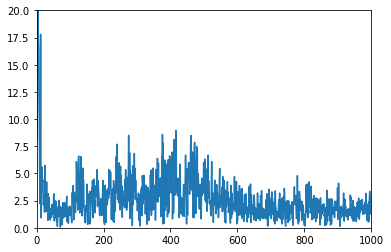

In [30]:
# Kun's suggestion: Fourier analysis

from scipy.fftpack import fft, ifft

rho = np.array(rho)

fft_rho = fft(rho) # all values
fft_rho = fft(rho[(rho[:] > r0)])   # just above r0

plt.plot(np.abs(fft_rho))
plt.xlim(0,1000)
plt.ylim(0,20)

plt.show()

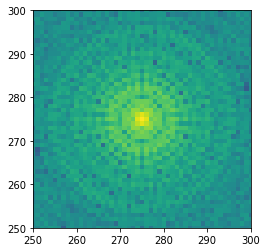

In [31]:
fft2_grid = np.fft.fftshift(np.fft.fft2(grid))
plt.imshow(np.log(abs(fft2_grid)))
plt.xlim(250,300)
plt.ylim(250,300)
plt.show()

N =  100025


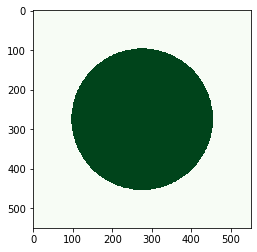

In [32]:
# repeating the above analysis for a true disc shaped lawn, for comparison

grid = np.zeros((gridsize, gridsize), dtype=int)

for i in range(gridsize):
    for j in range(gridsize):
        if np.sqrt((i-gridsize/2)**2+(j-gridsize/2)**2) < r0/cellwidth:
            grid[i,j]=1

# the number of spins does not quite match, but this is close enough
print("N = ", np.sum(grid))
            
plt.imshow(grid, interpolation='None', cmap='Greens')
plt.show()

In [33]:
# configuration center of mass

com=np.zeros(2)

for i in range(gridsize):
    for j in range(gridsize):
        com[0]+=grid[i,j]*i
        com[1]+=grid[i,j]*j
            
com = com/np.sum(grid)

print(com) # by design this is exactly centered

[275. 275.]


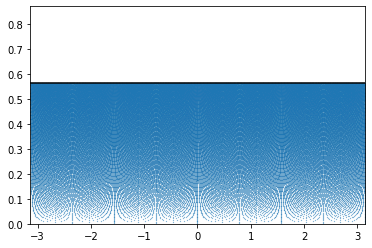

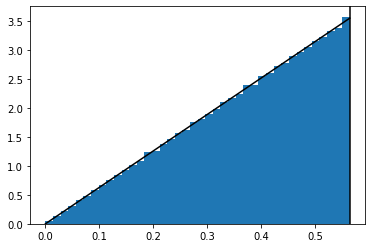

In [34]:
# configuration polar representation

phi_disc = []
rho_disc = []

for i in range(gridsize):
    for j in range(gridsize):
        if grid[i,j] == 1:
            x = (i - com[0])*cellwidth
            y = (j - com[1])*cellwidth
            phi_disc.append(np.arctan2(y,x))
            rho_disc.append(np.sqrt(x*x+y*y))

# polar representation: as expected, uniform in phi and all r-values are <= r0
# the density modulation is due to the polar measure r*dr
plt.ylim(0,gridsize/2*cellwidth)
plt.xlim(-np.pi,np.pi)
plt.scatter(phi_disc, rho_disc, s=0.05)
plt.axhline(r0, color='k')
plt.show()

# histogram of radii: as expected, the frequency of each r <= r0 is 2*pi*r
bins=40
plt.hist(rho_disc, bins=bins, density=True)
plt.axvline(r0, color='k')
hor = np.linspace(0,r0,100)
plt.plot(hor, 2*np.pi*hor, color='k')
plt.show()

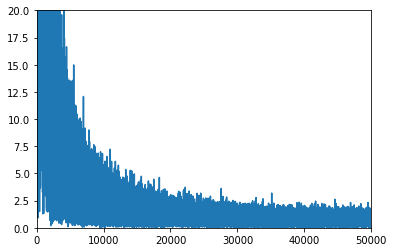

In [35]:
# Kun's suggestion: Fourier analysis

from scipy.fftpack import fft, ifft

rho = np.array(rho)

fft_rho = fft(rho) # all values

plt.plot(np.abs(fft_rho))
plt.xlim(0,len(fft_rho)/2)
plt.ylim(0,20)

plt.show()

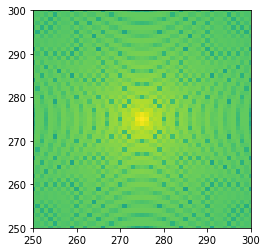

In [36]:
fft2_grid = np.fft.fftshift(np.fft.fft2(grid))
plt.imshow(np.log(abs(fft2_grid)))
plt.xlim(250,300)
plt.ylim(250,300)
plt.show()